In [10]:
# Configuração geral
CONFIG = {
    "img_size": 224,
    "batch_size": 32,
    "epochs": 25,
    "lr": 1e-4,
    "num_workers": 2,
    "dataset_path": "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017",
    "num_classes": 2,
    "model_name": "comparison_cnn_vs_densenet"
}


In [11]:
# imports
import os, json, torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
# relatorio, matriz de confusao e visualização
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device:', device)


Device: cuda


In [12]:
# Dataset (Base para CNN e DenseNet)
# Usada para cnn construida, densenet, treino e teste (nao muda entre os modelos)
class CocoBinaryDataset(Dataset):
    def __init__(self, image_dir, annotation_file, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        with open(annotation_file) as f:
            data = json.load(f)
        self.images = data['images']
        self.annotations = data['annotations']
        self.labels = {img['id']: 0 for img in self.images}
        for ann in self.annotations:
            if ann['category_id'] == 1:
                self.labels[ann['image_id']] = 1

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        path = os.path.join(self.image_dir, img_info['file_name'])
        # contorno para crashes no kaggle relativos a imagem
        try:
            image = Image.open(path).convert('RGB')
        except:
            return self.__getitem__((idx + 1) % len(self.images))
        
        label = int(self.labels[img_info['id']])
        if self.transform:
            image = self.transform(image)
        return image, label

In [13]:
"""
Pré-processamento e data augmentation.

transform_train: usado exclusivamente no treino. Aplica três técnicas
de augmentation que aumentam artificialmente a diversidade do dataset
sem coletar novas imagens:
  - RandomHorizontalFlip: espelha 50% das imagens horizontalmente.
    Pessoas continuam sendo pessoas independente do lado.
  - RandomRotation(15): gira a imagem em até 15° para qualquer lado,
    simulando variação de ângulo de captura.
  - ColorJitter: varia brilho e contraste em até 20%, simulando
    diferentes condições de iluminação.

transform_test: usado em teste. Sem augmentation — avaliação deve
ser determinística e reproduzível.

A normalização usa as estatísticas do ImageNet (mean/std padrão),
obrigatória para os modelos de transfer learning pré-treinados.
"""
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

transform_train = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

print(transform_train)


Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=None, hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [15]:
# Dataset + DataLoaders (Base do Experimento)
# Usada or cnn construída, densenet. Obs.: Não duplicar
# =========================
# dataset de treino
# =========================
train_dataset = CocoBinaryDataset(
    image_dir=f"{CONFIG['dataset_path']}/train2017",
    annotation_file=f"{CONFIG['dataset_path']}/annotations/instances_train2017.json",
    transform=transform_train
)

# Reduzindo o dataset de treino
import random
from torch.utils.data import Subset, DataLoader
# melhoria: garantindo que serão pegas as mesmas imagens
# garantindo resultados comparáveis entre cnn e a densenet
random.seed(42)
#.
train_indices = random.sample(range(len(train_dataset)), 5000)
train_dataset = Subset(train_dataset, train_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers']
)

# =========================
# dataset de teste
# =========================
test_dataset = CocoBinaryDataset(
    image_dir=f"{CONFIG['dataset_path']}/val2017",
    annotation_file=f"{CONFIG['dataset_path']}/annotations/instances_val2017.json",
    transform=transform
)

# Reduzindo também (pra ficar rápido)
test_indices = random.sample(range(len(test_dataset)), 1000)
test_dataset = Subset(test_dataset, test_indices)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    # nao embaralhar no teste
    shuffle=False,  
    num_workers=CONFIG['num_workers']
)

# sanity check
view_sanity_check = False
if view_sanity_check:
    print(f"Treino: {len(train_dataset)} imagens")
    print(f"Teste: {len(test_dataset)} imagens")

In [16]:
"""
CNN da Equipe 2 — arquitetura própria treinada do zero.

Estrutura:
  - 3 blocos convolucionais (Conv → ReLU → MaxPool)
    com filtros crescentes (32 → 64 → 128).
  - AdaptiveAvgPool(4x4) para garantir saída de tamanho fixo
    independente da resolução de entrada.
  - 2 camadas densas (2048 → 128 → 2 classes).

Regularização:
  - Dropout(p=0.5) entre as camadas densas. Durante o treino,
    desliga aleatoriamente 50% dos neurônios da camada fc1, forçando
    a rede a aprender representações mais robustas e reduzindo
    overfitting. No modo eval(), o Dropout é automaticamente
    desligado pelo PyTorch.

Servida como baseline para comparar contra modelos pré-treinados
(transfer learning) — demonstra a vantagem de TL com dados limitados.
"""
import torch.nn.functional as F

class cnn_equipe2(nn.Module):
    def __init__(self):
        super(cnn_equipe2, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3,   out_channels=32,  kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32,  out_channels=64,  kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64,  out_channels=128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.dropout = nn.Dropout(p=0.5)

        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, CONFIG['num_classes'])

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = self.adaptive_pool(x)
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

model_cnn = cnn_equipe2().to(device)

cnn_equipe2(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool2d(output_size=(4, 4))
  (dropout): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


In [17]:
"""
Transfer Learning com ResNet50.

ResNet50 (He et al., 2015): arquitetura com skip connections (conexões
residuais) que permitem treinar redes muito profundas sem o problema
de vanishing gradients. Padrão da indústria, usada como baseline
universal em tarefas de visão computacional.

Estratégia de TL: feature extraction. Os pesos do backbone (camadas
convolucionais) são congelados e apenas a camada final (model.fc) é
substituída e treinada para a tarefa binária (pessoa vs não pessoa).

Diferença vs DenseNet: a camada final da ResNet se chama 'fc' (fully
connected), não 'classifier'.
"""
model_resnet = models.resnet50(pretrained=True)

for param in model_resnet.parameters():
    param.requires_grad = False

model_resnet.fc = nn.Linear(
    model_resnet.fc.in_features,
    CONFIG['num_classes']
)

model_resnet = model_resnet.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s] 


In [18]:
"""
Transfer Learning com MobileNetV2.

MobileNetV2 (Sandler et al., 2018): arquitetura projetada para
dispositivos móveis e sistemas embarcados. Usa depthwise separable
convolutions e inverted residuals para ser ~10x mais leve que
ResNet50 mantendo boa acurácia.

Estratégia de TL: feature extraction. Backbone congelado, apenas
classifier[1] (a Linear final dentro do nn.Sequential) é substituída.

Diferença vs ResNet: a camada final é model.classifier[1], não
model.fc — ela está aninhada dentro de um nn.Sequential.
"""
model_mobile = models.mobilenet_v2(pretrained=True)

for param in model_mobile.parameters():
    param.requires_grad = False

model_mobile.classifier[1] = nn.Linear(
    model_mobile.classifier[1].in_features,
    CONFIG['num_classes']
)

model_mobile = model_mobile.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 97.1MB/s]


In [19]:
# Transfer Learning com Densenet
model_dense = models.densenet121(pretrained=True)

# congelar as features
for param in model_dense.features.parameters():
    param.requires_grad = False

# adaptar classificador (camada densa)
model_dense.classifier = nn.Linear(
    model_dense.classifier.in_features,
    CONFIG['num_classes']
)

model_dense = model_dense.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 130MB/s] 


In [20]:
# Setup de treino
# Meta: suportar model_cnn (cnn da equipe 2) e model_dense

# Loss mesma para os dois modelos
criterion = nn.CrossEntropyLoss()

# Otimização

# CNN da equipe 2
# Melhoria: aumentado o learning rate da CNNEquipe2
# optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=CONFIG['lr'])
# Testado com 15 e 25 epocas
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=1e-3)
# TODO: Testar respectivamente de 25 a 30 epocas
# optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=5e-4)
# optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=2e-3)
# .
# DenseNet (só treina o classificador)
optimizer_dense = optim.Adam(model_dense.classifier.parameters(), lr=CONFIG['lr'])

In [22]:
def train_model(model, optimizer, name="Model"):
    """
    Treina um modelo por CONFIG['epochs'] épocas e retorna os históricos
    de loss de treino e teste por época.

    Modificação importante: a função agora avalia o modelo no test_loader
    ao final de cada época, registrando o loss de teste. Isso permite
    plotar curvas de treino vs teste no mesmo gráfico, fundamental para
    diagnosticar overfitting visualmente — quando as duas curvas se
    separam, é sinal de que o modelo está decorando o treino e perdendo
    capacidade de generalização.

    Detalhes técnicos:
      - model.train() na fase de treino: ativa Dropout.
      - model.eval() na fase de avaliação: desliga Dropout para que
        a medição seja determinística.
      - torch.no_grad() na avaliação: economiza memória e tempo,
        já que não precisamos calcular gradientes.

    Args:
        model: modelo PyTorch a ser treinado.
        optimizer: otimizador configurado externamente para o modelo.
        name: string identificadora do modelo, usada nos prints.

    Returns:
        tuple:
            - train_history (list[float]): loss médio de treino por época.
            - test_history  (list[float]): loss médio de teste por época.
    """
    print(f"\nTreinando: {name}")
    train_history = []
    test_history  = []

    for epoch in range(CONFIG['epochs']):
        model.train()
        total_train_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device).long()

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_history.append(avg_train_loss)

        model.eval()
        total_test_loss = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images = images.to(device)
                labels = labels.to(device).long()

                outputs = model(images)
                loss = criterion(outputs, labels)

                total_test_loss += loss.item()

        avg_test_loss = total_test_loss / len(test_loader)
        test_history.append(avg_test_loss)

        print(f"  Epoch {epoch+1:02d}/{CONFIG['epochs']} - "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Test Loss: {avg_test_loss:.4f}")

    return train_history, test_history

In [24]:
def evaluate_model(model, name="Model"):
    """
    Avalia um modelo no test_loader e retorna métricas consolidadas.

    Modificação em relação à versão anterior: além de accuracy, labels
    e preds, agora retorna um dict com precision, recall e F1 por classe
    — necessário para a tabela comparativa final.

    Args:
        model: modelo PyTorch já treinado.
        name: string identificadora do modelo, usada nos prints.

    Returns:
        tuple:
            - accuracy (float): acurácia global no conjunto de teste.
            - all_labels (list): rótulos reais.
            - all_preds (list): predições do modelo.
            - metrics (dict): accuracy, precision, recall, f1 (macro avg).
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device).long()

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    report = classification_report(
        all_labels, all_preds,
        target_names=["Não pessoa", "Pessoa"],
        output_dict=True
    )

    accuracy = report["accuracy"]
    macro = report["macro avg"]

    metrics = {
        "accuracy":  round(accuracy, 4),
        "precision": round(macro["precision"], 4),
        "recall":    round(macro["recall"], 4),
        "f1":        round(macro["f1-score"], 4),
    }

    print(f"\n{name} — Accuracy: {metrics['accuracy']:.4f} | "
          f"F1: {metrics['f1']:.4f}")

    return accuracy, all_labels, all_preds, metrics

In [25]:
def get_fresh_models():
    """
    Instancia os 4 modelos com pesos pré-treinados do zero.

    Necessário para garantir que todos os modelos partem do mesmo
    ponto antes do treinamento. Retorna lista de tuplas
    (model, optimizer, name).
    """
    cnn = cnn_equipe2().to(device)

    dense = models.densenet121(pretrained=True)
    for param in dense.features.parameters():
        param.requires_grad = False
    dense.classifier = nn.Linear(dense.classifier.in_features, CONFIG['num_classes'])
    dense = dense.to(device)

    resnet = models.resnet50(pretrained=True)
    for param in resnet.parameters():
        param.requires_grad = False
    resnet.fc = nn.Linear(resnet.fc.in_features, CONFIG['num_classes'])
    resnet = resnet.to(device)

    mobile = models.mobilenet_v2(pretrained=True)
    for param in mobile.parameters():
        param.requires_grad = False
    mobile.classifier[1] = nn.Linear(mobile.classifier[1].in_features, CONFIG['num_classes'])
    mobile = mobile.to(device)

    return [
        (cnn,    optim.Adam(cnn.parameters(),                  lr=1e-3),           "CNNEquipe2"),
        (dense,  optim.Adam(dense.classifier.parameters(),     lr=CONFIG['lr']),   "DenseNet121"),
        (resnet, optim.Adam(resnet.fc.parameters(),            lr=CONFIG['lr']),   "ResNet50"),
        (mobile, optim.Adam(mobile.classifier[1].parameters(), lr=CONFIG['lr']),   "MobileNetV2"),
    ]

In [16]:
"""
Hold-out com 5 execuções.

Atende ao requisito 4.1.b do enunciado: hold-out com 5 execuções,
variando a seed de aleatoriedade do treino (inicialização de pesos,
shuffle do DataLoader e Dropout) enquanto mantém o split de dados
fixo (mesmos 5000 train / 1000 test em todas as execuções).

Para cada execução, armazena:
  - train_history e test_history (loss por época) → curvas de loss
  - accuracy, precision, recall, f1 (macro avg) → tabela final
  - labels e preds → matriz de confusão
  - confusion_matrix → análise detalhada por classe

Resultado final: dicionário 'results' com 5 valores por métrica para
cada modelo, permitindo calcular média ± desvio padrão.
"""
import random
from sklearn.metrics import confusion_matrix

NUM_RUNS = 5
SEEDS = [42, 43, 44, 45, 46]
MODEL_NAMES = ["CNNEquipe2", "DenseNet121", "ResNet50", "MobileNetV2"]

results = {
    name: {
        "accuracy":  [],
        "precision": [],
        "recall":    [],
        "f1":        [],
        "train_histories":     [],
        "test_histories":      [],
        "labels_per_run":      [],
        "preds_per_run":       [],
        "confusion_matrices":  [],
        "final_state_dict":    None,
    }
    for name in MODEL_NAMES
}

for run_idx, seed in enumerate(SEEDS, start=1):
    print(f"\n{'='*60}")
    print(f"EXECUÇÃO {run_idx}/{NUM_RUNS} — seed={seed}")
    print(f"{'='*60}")

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    models_list = get_fresh_models()

    for model, optimizer, name in models_list:
        train_hist, test_hist = train_model(model, optimizer, name=name)

        _, all_labels, all_preds, metrics = evaluate_model(model, name=name)

        results[name]["accuracy"].append(metrics["accuracy"])
        results[name]["precision"].append(metrics["precision"])
        results[name]["recall"].append(metrics["recall"])
        results[name]["f1"].append(metrics["f1"])

        results[name]["train_histories"].append(train_hist)
        results[name]["test_histories"].append(test_hist)

        results[name]["labels_per_run"].append(all_labels)
        results[name]["preds_per_run"].append(all_preds)

        cm = confusion_matrix(all_labels, all_preds)
        results[name]["confusion_matrices"].append(cm)

        if run_idx == NUM_RUNS:
            results[name]["final_state_dict"] = {
                k: v.cpu().clone() for k, v in model.state_dict().items()
            }


print(f"\n{'='*60}")
print(f"✅ {NUM_RUNS} execuções concluídas para os {len(MODEL_NAMES)} modelos!")
print(f"{'='*60}")


Treinando: CNNEquipe2
  Epoch 1/25 - Loss: 0.6785
  Epoch 2/25 - Loss: 0.6649
  Epoch 3/25 - Loss: 0.6562
  Epoch 4/25 - Loss: 0.6422
  Epoch 5/25 - Loss: 0.6302
  Epoch 6/25 - Loss: 0.6227
  Epoch 7/25 - Loss: 0.6152
  Epoch 8/25 - Loss: 0.5987
  Epoch 9/25 - Loss: 0.5939
  Epoch 10/25 - Loss: 0.5860
  Epoch 11/25 - Loss: 0.5684
  Epoch 12/25 - Loss: 0.5628
  Epoch 13/25 - Loss: 0.5541
  Epoch 14/25 - Loss: 0.5328
  Epoch 15/25 - Loss: 0.5194
  Epoch 16/25 - Loss: 0.5027
  Epoch 17/25 - Loss: 0.4946
  Epoch 18/25 - Loss: 0.4720
  Epoch 19/25 - Loss: 0.4576
  Epoch 20/25 - Loss: 0.4382
  Epoch 21/25 - Loss: 0.4258
  Epoch 22/25 - Loss: 0.4074
  Epoch 23/25 - Loss: 0.3926
  Epoch 24/25 - Loss: 0.3556
  Epoch 25/25 - Loss: 0.3443

CNNEquipe2 — Accuracy: 0.6910 | F1: 0.6905

Treinando: DenseNet121
  Epoch 1/25 - Loss: 0.6259
  Epoch 2/25 - Loss: 0.4846
  Epoch 3/25 - Loss: 0.4236
  Epoch 4/25 - Loss: 0.3944
  Epoch 5/25 - Loss: 0.3700
  Epoch 6/25 - Loss: 0.3517
  Epoch 7/25 - Loss: 0.34

## Experimento

Treinamento e avaliação de 4 arquiteturas para classificação binária (pessoa vs não pessoa) no COCO 2017.

| Modelo | Estratégia | Parâmetros treináveis |
|---|---|---|
| CNNEquipe2 | Treinado do zero | ~270k |
| DenseNet121 | Transfer Learning (feature extraction) | ~2k |
| ResNet50 | Transfer Learning (feature extraction) | ~4k |
| MobileNetV2 | Transfer Learning (feature extraction) | ~2.5k |


In [26]:
"""
Matrizes de confusão para os 4 modelos.

Como temos 5 execuções por modelo, plotamos a matriz da execução de
mediana performance (em F1) para cada modelo — representativa do
comportamento típico, evitando viés de pegar a melhor ou pior corrida.

Para cada modelo, mostra:
  - Verdadeiros Negativos (TN, canto superior esquerdo)
  - Falsos Positivos     (FP, canto superior direito)
  - Falsos Negativos     (FN, canto inferior esquerdo)
  - Verdadeiros Positivos (TP, canto inferior direito)
"""
def plot_confusion_matrix_from_cm(cm, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Não pessoa", "Pessoa"],
                yticklabels=["Não pessoa", "Pessoa"])
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title(title)
    plt.show()


for name in MODEL_NAMES:
    f1_scores = results[name]["f1"]
    median_idx = np.argsort(f1_scores)[len(f1_scores) // 2]
    cm = results[name]["confusion_matrices"][median_idx]

    plot_confusion_matrix_from_cm(
        cm,
        f"{name} — execução mediana (run {median_idx + 1}, F1={f1_scores[median_idx]:.4f})"
    )

NameError: name 'MODEL_NAMES' is not defined

## Curvas de Aprendizado

Evolução do loss médio por época durante o treinamento. Modelos com Transfer Learning tendem a convergir mais rápido por aproveitarem features já aprendidas no ImageNet.

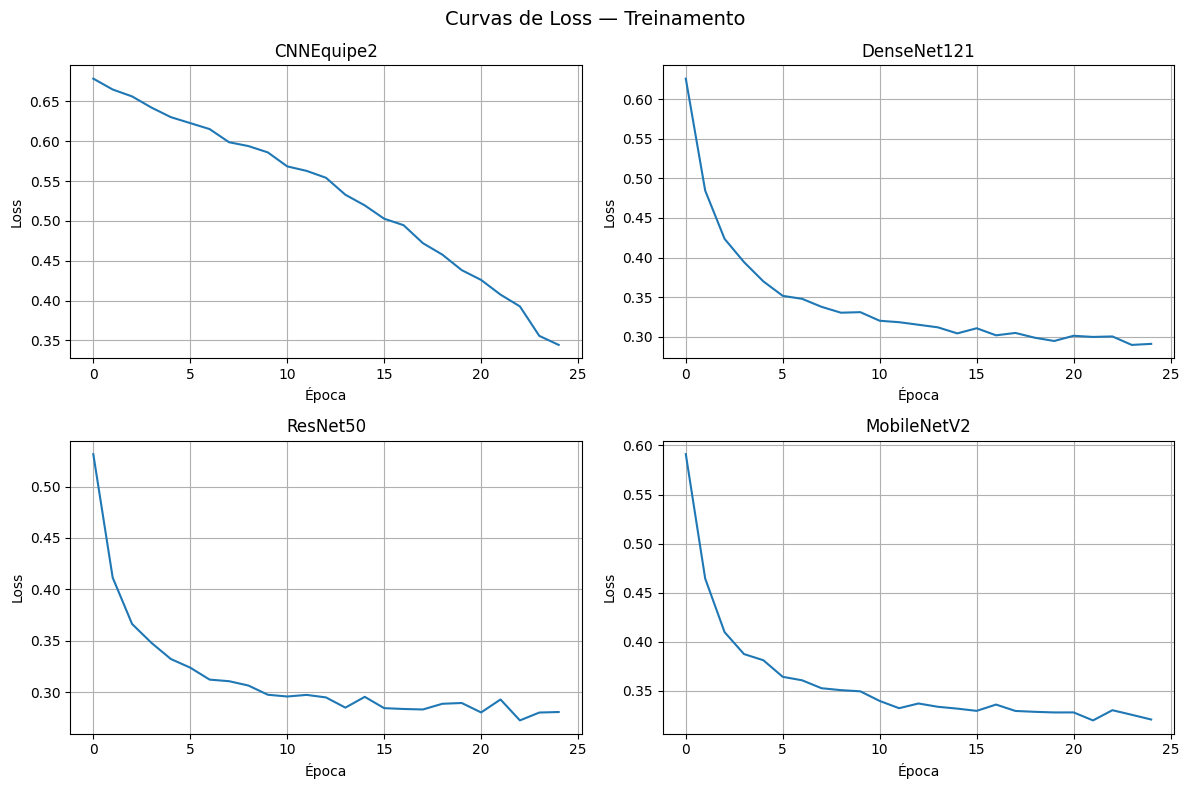

In [19]:
"""
Curvas de loss por época para os 4 modelos — treino vs teste.

Plota as 5 execuções de cada modelo (linhas finas/translúcidas) e a
média entre elas (linha grossa) para treino e teste no mesmo gráfico.
Isso permite diagnosticar:
  - Convergência: quando a loss para de cair.
  - Overfitting: quando a curva de teste sobe enquanto a de treino
    continua caindo (separação visual entre as duas).
  - Variância entre execuções: quão dispersas as curvas individuais
    estão em relação à média.
"""
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, name in enumerate(MODEL_NAMES):
    ax = axes[i]

    train_runs = np.array(results[name]["train_histories"])
    test_runs  = np.array(results[name]["test_histories"])

    epochs = np.arange(1, train_runs.shape[1] + 1)

    for run_idx in range(train_runs.shape[0]):
        ax.plot(epochs, train_runs[run_idx], color='steelblue', alpha=0.25, linewidth=1)
        ax.plot(epochs, test_runs[run_idx],  color='crimson',   alpha=0.25, linewidth=1)

    ax.plot(epochs, train_runs.mean(axis=0), color='steelblue', linewidth=2.5, label='Treino (média)')
    ax.plot(epochs, test_runs.mean(axis=0),  color='crimson',   linewidth=2.5, label='Teste (média)')

    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Época")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.4)
    ax.legend(loc='upper right')

plt.suptitle("Curvas de Loss — Treino vs Teste (5 execuções)", fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

## Resultados Comparativos

Métricas finais no conjunto de teste (1000 imagens do COCO val2017).

In [20]:
"""
Tabela comparativa das métricas dos 4 modelos.

Reporta média ± desvio padrão das 5 execuções para cada métrica.
Cumpre o requisito 5 do enunciado: "tabela resumo, com cada uma
das execuções vs métricas".

Duas tabelas são geradas:
  1. Tabela detalhada: 4 modelos × 5 execuções, valores individuais.
  2. Tabela resumo:    4 modelos × 4 métricas (média ± std).
"""
import pandas as pd

print("=" * 70)
print("TABELA 1 — Resultados por execução (4 modelos × 5 execuções)")
print("=" * 70)

detailed_rows = []
for name in MODEL_NAMES:
    for run_idx in range(NUM_RUNS):
        detailed_rows.append({
            "Modelo":    name,
            "Execução":  run_idx + 1,
            "Accuracy":  results[name]["accuracy"][run_idx],
            "Precision": results[name]["precision"][run_idx],
            "Recall":    results[name]["recall"][run_idx],
            "F1":        results[name]["f1"][run_idx],
        })

df_detailed = pd.DataFrame(detailed_rows)
print(df_detailed.to_string(index=False))

print("\n" + "=" * 70)
print("TABELA 2 — Resumo (média ± desvio padrão)")
print("=" * 70)

summary_rows = []
for name in MODEL_NAMES:
    row = {"Modelo": name}
    for metric in ["accuracy", "precision", "recall", "f1"]:
        values = np.array(results[name][metric])
        row[metric.capitalize()] = f"{values.mean():.4f} ± {values.std():.4f}"
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).set_index("Modelo")
print(df_summary.to_string())

             Accuracy  Precision  Recall      F1
Modelo                                          
CNNEquipe2      0.691     0.6908  0.6918  0.6905
DenseNet121     0.867     0.8678  0.8696  0.8669
ResNet50        0.861     0.8602  0.8603  0.8603
MobileNetV2     0.869     0.8688  0.8707  0.8688


In [21]:
# setup para visualizar as imagens por página
# de acordo com os modelos
import matplotlib.pyplot as plt
# melhoria:
# para nao ter que visualizar com as cores ruins (normalizadas)
def denormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img.cpu().permute(1, 2, 0).numpy()
    img = std * img + mean
    img = np.clip(img, 0, 1)

    return img
# .
classes = ["Não pessoa", "Pessoa"]

def show_batch(images, labels, preds):
    plt.figure(figsize=(12, 6))

    for i in range(len(images)):
        # melhoria
        #img = images[i].cpu().permute(1, 2, 0).numpy()
        img = img = denormalize(images[i])
        # .
        real = labels[i]
        prev = preds[i]

        if real == prev:
            color = "white"
            backgroundcolor = "green"
        else:
            color = "white"
            backgroundcolor = "red"

        title = f"Real: {classes[real]}\nPrev: {classes[prev]}"

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(title, fontsize=12, color=color, backgroundcolor=backgroundcolor)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def visualize_model(model, name="Modelo"):
    print(f"\n🔍 Visualizando: {name}")
    
    model.eval()

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(test_loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            print(f"Página {batch_idx + 1}")
            show_batch(images[:8], labels[:8], preds[:8])

            if batch_idx == 4:
                break

def visualizar(opcao=False):
    if opcao == 'modelo-equipe':
        visualize_model(model_cnn, "CNNEquipe2")
    if opcao == 'modelo-densenet':
        visualize_model(model_dense, "DenseNet")
    if not opcao:
        print("visualizar(opcao=['modelo-equipe' | 'desenet']")


🔍 Visualizando: CNNEquipe2
Página 1


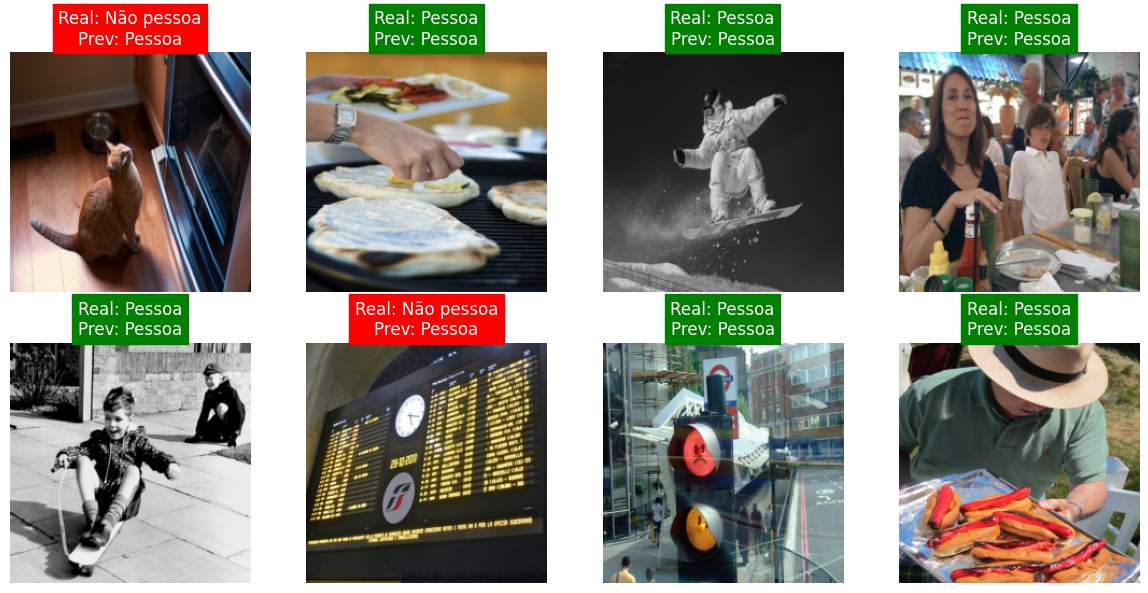

Página 2


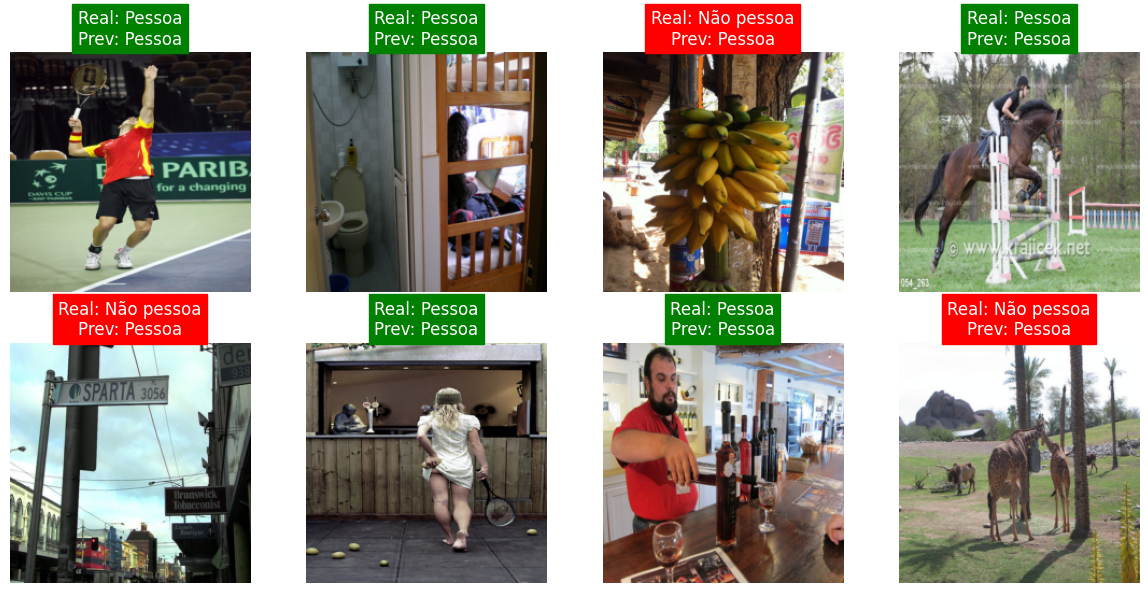

Página 3


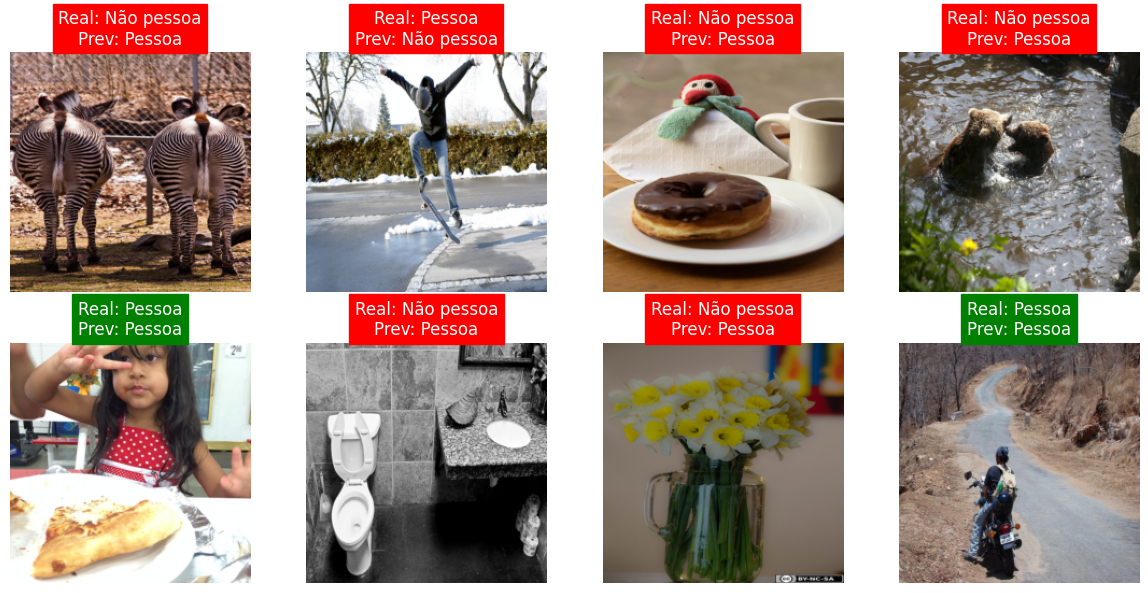

Página 4


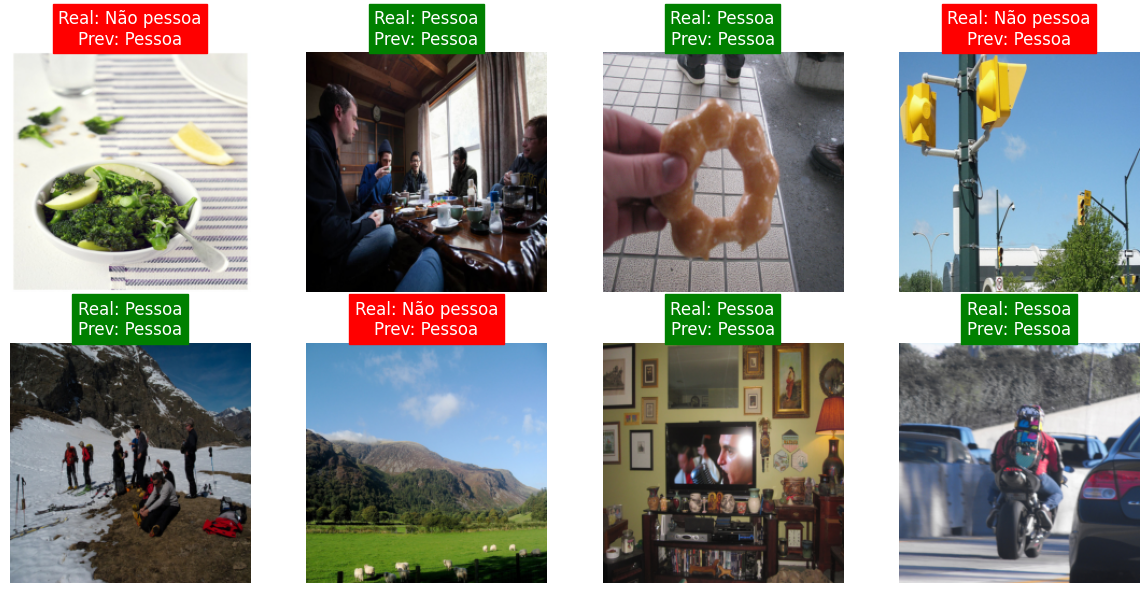

Página 5


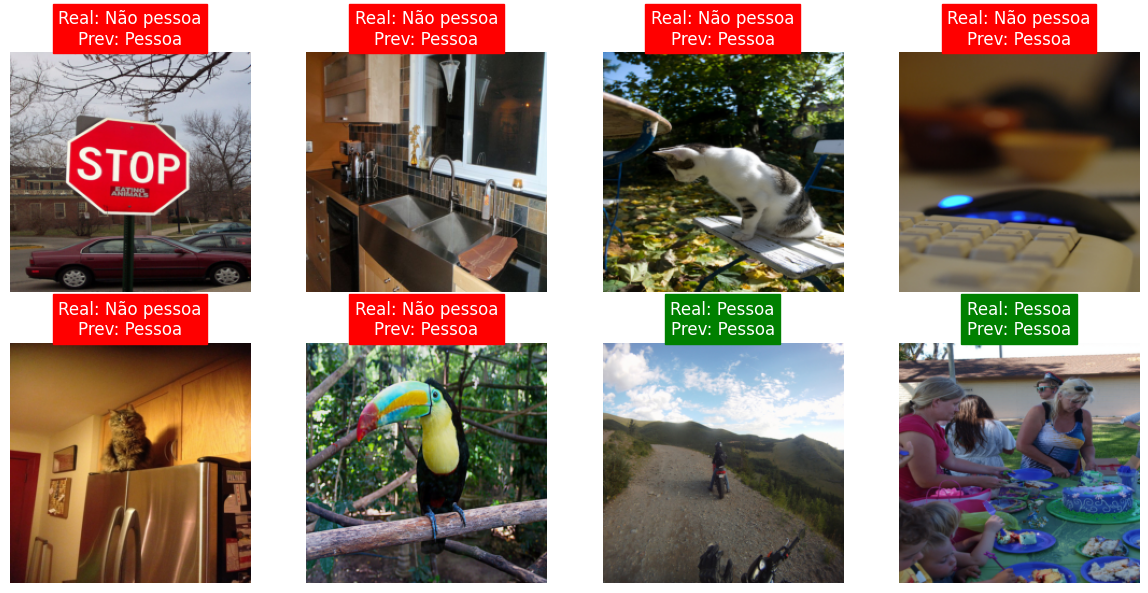

In [22]:
"""
Visualização qualitativa — CNN da Equipe 2 treinada.

Recria a instância do cnn_equipe2 e carrega os pesos da última
execução (seed=46) salvos no loop de treino. Mostra acertos (verde)
e erros (vermelho) em batches do test_loader.

A escolha da execução final é arbitrária — representa o comportamento
típico do modelo. As métricas oficiais são média ± std das 5 execuções
reportadas na tabela final.
"""
model_cnn_trained = cnn_equipe2().to(device)
model_cnn_trained.load_state_dict(results["CNNEquipe2"]["final_state_dict"])
model_cnn_trained.eval()

visualize_model(model_cnn_trained, "CNNEquipe2 (treinada)")